In [29]:
# Импорты сюдаа
import numpy as np
import matplotlib.pyplot as plt
import segyio
import segyio.tools
from scipy.signal import correlate
from scipy.stats import spearmanr, pearsonr, norm
from scipy.signal import find_peaks, hilbert
from scipy.optimize import minimize_scalar, minimize
from scipy.optimize import minimize, differential_evolution
from typing import List, Dict, Tuple, Callable
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import warnings
#warnings.filterwarnings('ignore')

In [30]:
class RickerWaveletGenerator:
    """
    Генератор синтетических сейсмических трасс на основе свёрточной модели.
    """
    
    def __init__(self, wavelet_type='ricker', wavelet_freq=30, dt=0.002, length=0.128):
        """
        Инициализация генератора.
        ----------
        wavelet_type : str                тип вейвлета по умолчанию ('ricker', других пока нет)
        wavelet_freq : float              доминантная частота вейвлета в Гц (чем выше частота, тем уже импульс)
        dt : float                        интервал дискретизации в секундах (шаг по времени)
        length : float                    полная длина вейвлета в секундах по умолчанию (от -length/2 до length/2)
        """
        self.wavelet_type = wavelet_type
        self.wavelet_freq = wavelet_freq
        self.length = length
        self.dt = dt
    
        self.wavelet_time, self.wavelet = self._create_ricker_wavelet()
    
    def _create_ricker_wavelet(self):
        """
        Создание вейвлета Рикера. Формула: (1 - 2π²f²t²) * exp(-π²f²t²), где f - доминантная частота, t - время
        ----------
        wavelet_time : np.ndarray          временная ось вейвлета (от -length/2 до length/2 с шагом dt)
        wavelet : np.ndarray               амплитуды вейвлета (не нормированные)
        """
        # Временная сетка для импульса
        t = np.arange(-self.length/2, self.length/2, self.dt) #создаёт массив чисел от -self.length/2 (-0.064) до self.length/2 (0.064) с шагом self.dt (0.002 сек)
        f = self.wavelet_freq
        
        tau = np.pi * f * t
        wavelet = (1 - 2 * tau**2) * np.exp(-tau**2)
        # Нормализация (максимальная амплитуда = 1)
        #wavelet = wavelet / np.max(np.abs(wavelet))
        
        return t, wavelet
    
    def get_wavelet(self):
        """
        Создаёт импульс источника (вейвлет), если ещё не создан, иначе возвращает существующий.
        ----------
        tuple : (wavelet_time, wavelet)      временная ось и амплитуды вейвлета
        """
        if self.wavelet is None:
            if self.wavelet_type == 'ricker':
                t, w = self._create_ricker_wavelet()
                self.wavelet_time = t
                self.wavelet = w
            else:
                raise ValueError(f"Неподдерживаемый тип вейвлета: {self.wavelet_type}")
                
        return self.wavelet_time, self.wavelet
    
    def generate_trace(self, reflectivity_series, noise_level=0.0):
        """
        Генерация сейсмической трассы по коэффициентам отражения.
        ----------
        reflectivity_series : np.ndarray                временной ряд коэффициентов отражения (импульсная характеристика среды); длина массиво определяет длительность трассы в отсчётах
        noise_level : float                             уровень шума (0 = без шума по умолчанию, 0.05 = 5% от RMS сигнала)
        ----------
        trace : np.ndarray                              синтетическая сейсмическая трасса (результат свёртки)
        ----------
        1. Вейвлет - 2. Выполнение свёртки: trace = reflectivity * wavelet - 3. Обрезка до длины исходного ряда - 4. Добавление шума (если необходимо)
        """
        # 1. Импульс источника
        wavelet = self.get_wavelet()
        # 2. Свёртка коэффициентов отражения с импульсом, 'full' -> полная свёртка, потом обрезаем до длины reflectivity_series
        trace_full = np.convolve(reflectivity_series, wavelet, mode='full')
        # 3. Обрезка до нужной длины (сохранение временной оси как у reflectivity_series)
        trace = trace_full[:len(reflectivity_series)]
        # 4. Шум
        if noise_level > 0:
            # Оценка RMS сигнала
            rms_signal = np.sqrt(np.mean(trace**2))
            
            noise = np.random.randn(len(trace)) * noise_level * rms_signal
            trace = trace + noise
        
        return trace
    
    def plot_wavelet(self):
        wavelet = self.get_wavelet()
        plt.figure(figsize=(5, 2))
        plt.plot(self.wavelet_time, wavelet)
        plt.title(f"Импульс источника по умолчанию ({self.wavelet_type}, freq={self.wavelet_freq} Гц)")
        plt.xlabel("Время (с)")
        plt.ylabel("Амплитуда")
        plt.grid(True)
        plt.show()

In [31]:
class ReflectionCoefficients:
    """
    Расчёт коэффициентов отражения для горизонтально-слоистой среды.
    """
    
    def __init__(self, depths, velocities, densities):
        """    
        ----------
        depths : np.ndarray                глубины границ от поверхности (м), длина = количество границ
        velocities : np.ndarray            скорости в слоях (м/с), длина = len(depths) + 1 (слой над первой границей + слои между границами + последний слой)
        densities : np.ndarray             плотности в слоях (кг/м³), длина = len(depths) + 1
        ----------
        1. Сохранение входных параметров - 2. Вычисление акустических импедансов слоёв - 3. Вычисление коэффициентов отражения на границах - 4. Вычисление двустороннего времени прихода отражений
        """
        self.depths = np.array(depths)
        self.velocities = np.array(velocities)
        self.densities = np.array(densities)
        self.num_layers = len(velocities)
        self.num_boundaries = len(depths)
        
        self.impedances = self._compute_impedances()
        self.reflection_coeffs = self._compute_reflection_coeffs()
        self.two_way_times = self._compute_times()
    
    def _compute_impedances(self):
        """
        Вычисление акустического импеданса для каждого слоя. Формула: Z = ρ * V, где ρ - плотность, V - скорость
        ----------
        impedances : np.ndarray                массив импедансов для всех слоёв (длина = количество слоёв)
        """
        return self.densities * self.velocities
    
    def _compute_reflection_coeffs(self):
        """
        Вычисление коэффициента отражения на каждой границе. Формула: R = (Z₂ - Z₁) / (Z₂ + Z₁), где Z₁ - импеданс верхнего слоя, Z₂ - импеданс нижнего слоя
        ----------
        R : np.ndarray               массив коэффициентов отражения (длина = количество границ)
        """
        R = []
        for i in range(self.num_boundaries):
            Z_upper = self.impedances[i]
            Z_lower = self.impedances[i+1]
            coeff = (Z_lower - Z_upper) / (Z_lower + Z_upper)
            R.append(coeff)
            
        return np.array(R)
    
    def _compute_times(self):
        """
        Вычисление двустороннего времени прихода отражённой волны от каждой границы.
        ----------
        Время = 2 * (толщина_слоя / скорость_слоя). Для каждой границы суммируется время прохождения всех вышележащих слоёв
        ----------
        times : np.ndarray            массив времён для каждой границы (в секундах)
        """
        times = []
        cumulative = 0.0
        
        for i in range(self.num_boundaries):
            if i == 0:
                thickness = self.depths[0]
            else:
                thickness = self.depths[i] - self.depths[i-1]
            
            cumulative += 2 * thickness / self.velocities[i]
            times.append(cumulative)
        
        return np.array(times)

        
    def get_impedances(self):
        return self.impedances

    def get_reflection_coeffs(self):
        return self.reflection_coeffs

    def get_two_way_times(self):
        return self.two_way_times

        
    def get_reflectivity_series(self, dt, total_time):
        """
        Преобразование коэффициентов отражения в дискретный временной ряд. Коэффициенты отражения размещаются на ближайших временных отсчётах с помощью округления (int(round(t / dt)))
        ----------
        dt : float                            интервал дискретизации в секундах
        total_time : float                    полное время записи в секундах
        ----------
        time_axis : np.ndarray                временная ось (от 0 до total_time с шагом dt)
        reflectivity_series : np.ndarray      временной ряд коэффициентов отражения (импульсы на временах границ)
        """
        num_samples = int(total_time / dt) + 1
        time_axis = np.arange(0, total_time + dt, dt)[:num_samples]
        reflectivity_series = np.zeros(num_samples)
        
        for t, r in zip(self.two_way_times, self.reflection_coeffs):
            idx = int(round(t / dt))
            if idx < num_samples:
                reflectivity_series[idx] = r
        
        return time_axis, reflectivity_series
    
    def print_summary(self):
        print("ГЕОЛОГИЧЕСКАЯ МОДЕЛЬ\n")
        
        print(f"{'Слой':<6} {'V (м/с)':<10} {'ρ (кг/м³)':<12} {'Z (кг/(м²·с))':<18} {'Толщина':<12}")
        print("-" * 70)
        # Слой 0 (до первой границы)
        print(f"{'0':<6} {self.velocities[0]:<10.0f} {self.densities[0]:<12.1f} {self.impedances[0]:<18.2f} {self.depths[0]:<12.1f} м")
        # Промежуточные слои
        for i in range(1, self.num_layers - 1):
            thickness = self.depths[i] - self.depths[i-1]
            print(f"{i:<6} {self.velocities[i]:<10.0f} {self.densities[i]:<12.1f} {self.impedances[i]:<18.2f} {thickness:<12.1f} м")
        # Последний слой (полубесконечный)
        if self.num_layers > 1:
            last_thickness = "∞"
            print(f"{self.num_layers-1:<6} {self.velocities[-1]:<10.0f} {self.densities[-1]:<12.1f} {self.impedances[-1]:<18.2f} {last_thickness:<12}")
        print("ГРАНИЦЫ\n")
        for i in range(self.num_boundaries):
            sign = "+" if self.reflection_coeffs[i] >= 0 else "-"
            print(f"Граница {i+1}: глубина {self.depths[i]} м, R = {self.reflection_coeffs[i]:.4f} ({sign}), t = {self.two_way_times[i]:.4f} с")


In [32]:
class SeismicTraceGenerator:
    """
    Генератор синтетической трассы с возможностью подбора параметров модели.
    """
    
    def __init__(self, wavelet_freq=30, dt=0.002, noise_level=0.0):
        """    
        Создание вейвлета с заданными параметрами для последующей свёртки.
        ----------
        wavelet_freq : float                доминантная частота вейвлета в Гц
        dt : float                          интервал дискретизации в секундах
        noise_level : float                 уровень шума (0 = без шума, 0.05 = 5% от RMS сигнала)
        """
        self.wavelet_freq = wavelet_freq
        self.dt = dt
        self.noise_level = noise_level
        self.total_time = None   # будет установлен позже
        self.time = None         # временная ось
        
        self.rc_model = None
        
        # Вейвлет
        wavelet = RickerWaveletGenerator(wavelet_freq=wavelet_freq, dt=dt, length=0.2)
        self.wavelet_time, self.wavelet = wavelet.get_wavelet()
    
    def set_model(self, depths, velocities, densities):
        """
        Установка геометрии слоёв через ReflectionCoefficients.
        ----------
        depths : array_like            глубины границ от поверхности (м)
        velocities : array_like        скорости в слоях (м/с) (len = len(depths) + 1)
        densities : array_like         плотности в слоях (кг/м³) (len = len(depths) + 1)
        """
        self.rc_model = ReflectionCoefficients(depths, velocities, densities)
    
    def set_horizons(self, depths, velocities, densities):
        """
        Установка геометрии слоёв (для обратной совместимости).
        ----------
        depths : array_like            глубины границ от поверхности (м)
        velocities : array_like        скорости в слоях (м/с) (len = len(depths) + 1)
        densities : array_like         плотности в слоях (кг/м³) (len = len(depths) + 1)
        """
        self.set_model(depths, velocities, densities)
    
    def set_wavelet_freq(self, freq):
        """Установка частоты вейвлета и его пересоздание."""
        self.wavelet_freq = freq
        wavelet = RickerWaveletGenerator(wavelet_freq=freq, dt=self.dt, length=0.2)
        self.wavelet_time, self.wavelet = wavelet.get_wavelet()
    
    def set_noise(self, noise_std):
        """Установка уровня шума."""
        self.noise_level = noise_std
    
    def set_total_time(self, total_time):
        """Установка полного времени записи и создание временной оси."""
        self.total_time = total_time
        self.time = np.arange(0, total_time, self.dt)
    
    def compute_reflectivity_series(self):
        """
        Вычисляет коэффициенты отражения по импедансам и времена прихода. Использует данные из объекта ReflectionCoefficients.
        ----------
        coeffs : np.ndarray            массив коэффициентов отражения
        times : np.ndarray             массив времён прихода (в секундах)
        """
        if self.rc_model is None:
            raise ValueError("Модель не установлена. Вызовите set_model() или set_horizons()")
        
        # Данные из готового объекта ReflectionCoefficients
        return self.rc_model.reflection_coeffs, self.rc_model.two_way_times
    
    def generate_from_reflectivity(self, reflectivity_series):
        """
        Генерация трассы из временного ряда коэффициентов отражения.
        ----------
        reflectivity_series : np.ndarray           временной ряд коэффициентов отражения
        ----------
        trace : np.ndarray                         сейсмическая трасса (результат свёртки с вейвлетом)
        """
        # Полная свёртка
        trace_full = np.convolve(reflectivity_series, self.wavelet, mode='full')
        # Обрезка до длины исходного ряда
        trace = trace_full[:len(reflectivity_series)]
        # МАСШТАБИРОВАНИЕ: приведение к уровню реальных данных
        SCALE_FACTOR = 100000
        trace = trace * SCALE_FACTOR
        # Шум
        trace = self._add_noise(trace)
        
        return trace
    
    def generate_trace(self):
        """
        Генерирует синтетическую трассу с текущими параметрами модели.
        ----------
        trace : np.ndarray            синтетическая трасса
        times : np.ndarray            времена прихода границ
        coeffs : np.ndarray           коэффициенты отражения
        """
        if self.total_time is None:
            raise ValueError("Полное время не установлено. Вызовите set_total_time()")
        
        if self.time is None:
            self.time = np.arange(0, self.total_time, self.dt)
        
        if self.rc_model is None:
            raise ValueError("Модель не установлена. Вызовите set_model() или set_horizons()")
        
        coeffs = self.rc_model.reflection_coeffs
        times = self.rc_model.two_way_times
        
        reflectivity = np.zeros(len(self.time))
        for t, r in zip(times, coeffs):
            idx = int(round(t / self.dt))
            if idx < len(reflectivity):
                reflectivity[idx] = r
        
        trace = self.generate_from_reflectivity(reflectivity)
        
        return trace, times, coeffs
    
    def generate_from_model(self, depths, velocities, densities, total_time):
        """
        Полный конвейер: геология → трасса. ГЛАВНАЯ ФУНКЦИЯ ГЕНЕРАЦИИ ТРАССЫ
        ----------
        time_axis, trace, rc_model
        """
        # Установка параметров модели через ReflectionCoefficients
        self.set_model(depths, velocities, densities)
        self.set_total_time(total_time)
        
        # Шаг 1: временной ряд коэффициентов (используем метод ReflectionCoefficients)
        time_axis, reflectivity = self.rc_model.get_reflectivity_series(self.dt, total_time)
        
        # Шаг 2: свёртка с вейвлетом
        trace = self.generate_from_reflectivity(reflectivity)
        
        return time_axis, trace, self.rc_model
    
    def compare_with_real(self, real_trace):
        """
        Сравнение синтетики с реальной трассой.
        ----------
        real_trace : np.ndarray            реальная трасса
        ----------
        metrics : dict                     метрики сравнения (pearson, spearman, mse, trace)
        """
        if self.time is None:
            raise ValueError("Временная ось не установлена. Вызовите set_total_time()")
        
        synth_trace, _, _ = self.generate_trace()
        min_len = min(len(synth_trace), len(real_trace))
        
        from scipy.stats import spearmanr
        
        return {
            'pearson': np.corrcoef(synth_trace[:min_len], real_trace[:min_len])[0, 1],
            'spearman': spearmanr(synth_trace[:min_len], real_trace[:min_len])[0],
            'mse': np.mean((synth_trace[:min_len] - real_trace[:min_len])**2),
            'trace': synth_trace
        }
    
    def _add_noise(self, trace):
        """
        Добавление шума к трассе с уровнем относительно RMS сигнала.
        """
        if self.noise_level <= 0:
            return trace
        
        rms = np.sqrt(np.mean(trace**2))
        if rms > 0:
            noise = np.random.randn(len(trace)) * self.noise_level * rms
            return trace + noise
        return trace
    
    def plot_comparison(self, real_trace):
        if self.time is None:
            raise ValueError("Временная ось не установлена. Вызовите set_total_time()")
        
        synth_trace, times, coeffs = self.generate_trace()
        min_len = min(len(synth_trace), len(real_trace))
        time_axis = self.time[:min_len]
        
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        # Трассы
        axes[0].plot(time_axis, real_trace[:min_len], 'b-', label='Реальная', alpha=0.8)
        axes[0].plot(time_axis, synth_trace[:min_len], 'r-', label='Синтетика', alpha=0.8)
        for t in times:
            axes[0].axvline(x=t, color='gray', linestyle='--', alpha=0.5)
        
        metrics = self.compare_with_real(real_trace)
        axes[0].set_title(f'Сравнение трасс (корр = {metrics["pearson"]:.3f})')
        axes[0].set_xlabel('Время (с)')
        axes[0].legend()
        axes[0].grid(True)
        # Разность
        diff = synth_trace[:min_len] - real_trace[:min_len]
        axes[1].plot(time_axis, diff, 'g-')
        axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3)
        axes[1].set_title(f'Разность (MSE = {metrics["mse"]:.6f})')
        axes[1].set_xlabel('Время (с)')
        axes[1].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    def visualize_full(self, depths, velocities, densities, total_time):
        """
        Комплексная визуализация всей цепочки:
        1. Скоростная модель
        2. Импедансы слоёв
        3. Коэффициенты отражения
        4. Синтетическая трасса
        """
        time_axis, trace, rc = self.generate_from_model(depths, velocities, densities, total_time)
        
        _, reflectivity = rc.get_reflectivity_series(self.dt, total_time)
        
        fig, axes = plt.subplots(4, 1, figsize=(10, 8))
        
        # 1. Скоростная модель
        depths_plot = [0] + list(depths)
        velocities_plot = velocities
        axes[0].step(depths_plot + [depths_plot[-1] + 500], 
                     velocities_plot + [velocities_plot[-1]], 
                     where='post', linewidth=2)
        axes[0].set_ylabel("Скорость V, м/с")
        axes[0].set_xlabel("Глубина, м")
        axes[0].grid(True)
        axes[0].set_title("1. Скоростная модель")
        # 2. Импедансы слоёв
        impedances = rc.impedances
        layer_names = [f"Слой {i+1}" for i in range(len(impedances))]
        axes[1].bar(layer_names, impedances, color='lightblue', edgecolor='black')
        axes[1].set_ylabel("Акустический импеданс Z = ρ·V")
        axes[1].set_title("2. Импедансы слоёв")
        axes[1].grid(True, axis='y')
        # 3. Коэффициенты отражения
        R = rc.reflection_coeffs
        boundary_names = [f"Гр.{i+1}" for i in range(len(R))]
        colors = ['green' if r >= 0 else 'red' for r in R]
        axes[2].bar(boundary_names, R, color=colors, edgecolor='black')
        axes[2].axhline(y=0, color='black', linewidth=1)
        axes[2].set_ylabel("Коэффициент отражения R")
        axes[2].set_title("3. Коэффициенты отражения на границах")
        axes[2].grid(True, axis='y')
        # 4. Синтетическая трасса
        axes[3].plot(time_axis, trace, 'b-', linewidth=1.5)
        axes[3].set_xlabel("Время, с")
        axes[3].set_ylabel("Амплитуда")
        axes[3].set_title("4. Синтетическая сейсмическая трасса")
        axes[3].grid(True)
        # Отмечаем времена прихода границ
        for t in rc.two_way_times:
            axes[3].axvline(x=t, color='red', linestyle='--', alpha=0.5, linewidth=1)
        
        plt.tight_layout()
        plt.show()
        
        return time_axis, trace, rc

In [33]:
class MonteCarloGenerator:
    """
    Генератор синтетических сейсмических трасс методом Монте-Карло. Позволяет учесть неопределённость геологических параметров и получить ансамбль трасс с последующим статистическим анализом.
    """
    
    def __init__(self, wavelet_freq=30, dt=0.002, total_time=5.0, noise_level=0.0):
        """
        ----------
        wavelet_freq : float            доминантная частота вейвлета (Гц)
        dt : float                      интервал дискретизации (с)
        total_time : float              полное время записи (с)
        noise_level : float             уровень шума (0 = без шума)
        """
        self.wavelet_freq = wavelet_freq
        self.dt = dt
        self.total_time = total_time
        self.noise_level = noise_level
        self.num_samples = int(total_time / dt) + 1
        self.time_axis = np.arange(0, total_time + dt, dt)[:self.num_samples]
        
        self.trace_gen = SeismicTraceGenerator(
            wavelet_freq=wavelet_freq, 
            dt=dt, 
            noise_level=noise_level
        )
        self.trace_gen.set_total_time(total_time)
    
    @staticmethod
    def sample_geology(distributions, enforce_sort=True):
        """
        Генерация одного случайного набора геологических параметров.
        ----------
        distributions : dict            словарь с распределениями для скоростей, плотностей и глубин.
            Формат:
            {
                'velocities': [{'type': 'normal', 'mu': 2000, 'sigma': 100}, ...],
                'densities': [{'type': 'normal', 'mu': 2100, 'sigma': 50}, ...],
                'depths': [{'type': 'uniform', 'low': 450, 'high': 550}, ...]
            }
            Поддерживаемые типы: 'normal', 'uniform', 'lognormal', 'fixed'
            
        enforce_sort : bool            сортировать глубины (обязательно для физической модели)
        ----------
        tuple : (depths, velocities, densities)
        """
        depths = []
        velocities = []
        densities = []
        
        # Глубины границ
        for d in distributions.get('depths', []):
            dist_type = d.get('type', 'fixed')
            if dist_type == 'uniform':
                h = np.random.uniform(d['low'], d['high'])
            elif dist_type == 'normal':
                h = np.random.normal(d['mu'], d['sigma'])
            elif dist_type == 'lognormal':
                h = np.random.lognormal(d['mu'], d['sigma'])
            else:
                h = d.get('value', 1000)
            depths.append(h)
        
        # Скорости слоёв
        for v in distributions.get('velocities', []):
            dist_type = v.get('type', 'fixed')
            if dist_type == 'normal':
                val = np.random.normal(v['mu'], v['sigma'])
            elif dist_type == 'uniform':
                val = np.random.uniform(v['low'], v['high'])
            elif dist_type == 'lognormal':
                val = np.random.lognormal(v['mu'], v['sigma'])
            else:
                val = v.get('value', 2500)
            # Ограничение возможных значений
            val = max(val, 500)
            velocities.append(val)
        
        # Плотности слоёв
        for r in distributions.get('densities', []):
            dist_type = r.get('type', 'fixed')
            if dist_type == 'normal':
                val = np.random.normal(r['mu'], r['sigma'])
            elif dist_type == 'uniform':
                val = np.random.uniform(r['low'], r['high'])
            elif dist_type == 'lognormal':
                val = np.random.lognormal(r['mu'], r['sigma'])
            else:
                val = r.get('value', 2200)
            # Огрантчение физических возможных значений
            val = max(val, 1500)
            densities.append(val)
        
        # Сортировка глубин по возрастанию
        depths = np.array(depths)
        if enforce_sort and len(depths) > 1:
            depths = np.sort(depths)
        
        return np.array(depths), np.array(velocities), np.array(densities)
    
    def generate_ensemble(self, distributions, M=100, verbose=True):
        """
        Генерация ансамбля из M трасс методом Монте-Карло.
        ----------
        distributions : dict            словарь с распределениями параметров из sample_geology
        M : int                         количество реализаций (трасс) в ансамбле
        verbose : bool                  выводить прогресс и информацию
        -------
        traces : np.ndarray             массив трасс размером (M, num_samples)
        time_axis : np.ndarray          временная ось
        all_params : list               список словарей с параметрами каждой модели
        """
        traces = []
        all_params = []
        successful = 0
        
        for i in range(M):
            if verbose and (i + 1) % 20 == 0:
                print(f"  Генерация реализации {i + 1}/{M}...")
            
            # Случайные параметры
            depths, velocities, densities = self.sample_geology(distributions)
            # Расчёт коэффициентов отражения
            try:
                rc = ReflectionCoefficients(depths, velocities, densities)
                time_axis, reflectivity = rc.get_reflectivity_series(self.dt, self.total_time)
            except Exception as e:
                if verbose:
                    print(f"  Предупреждение: ошибка в модели {i}: {e}")
                continue
                
            # Генерация трассы
            trace = self.trace_gen.generate_from_reflectivity(reflectivity)
            traces.append(trace)
            all_params.append({
                'depths': depths.tolist(),
                'velocities': velocities.tolist(),
                'densities': densities.tolist(),
                'coeffs': rc.reflection_coeffs.tolist(),
                'times': rc.two_way_times.tolist()
            })
            successful += 1
        
        traces = np.array(traces)
        
        if verbose:
            print(f"\nСгенерировано {successful} трасс из {M} попыток")
        
        return traces, self.time_axis, all_params
    
    @staticmethod
    def compute_statistics(traces):
        """
        Вычисление средней трассы, стандартного отклонения и 95% доверительных интервалов.
        ----------
        traces : np.ndarray            массив трасс размером (M, num_samples)
        -------
        dict : Словарь со статистиками
            - 'mean' : средняя трасса
            - 'std' : стандартное отклонение
            - 'ci_lower' : нижняя граница 95% ДИ
            - 'ci_upper' : верхняя граница 95% ДИ
            - 'p5' : 5-й процентиль
            - 'p95' : 95-й процентиль
        """
        mean_trace = np.mean(traces, axis=0)
        std_trace = np.std(traces, axis=0)
        n = len(traces)
        
        # 95% доверительный интервал (t-распределение для малых выборок)
        from scipy import stats
        t_val = stats.t.ppf(0.975, n - 1) if n > 1 else 1.96
        ci_lower = mean_trace - t_val * std_trace / np.sqrt(n)
        ci_upper = mean_trace + t_val * std_trace / np.sqrt(n)
        
        # Процентили (непараметрический подход)
        p5 = np.percentile(traces, 5, axis=0)
        p95 = np.percentile(traces, 95, axis=0)
        
        return {
            'mean': mean_trace,
            'std': std_trace,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'p5': p5,
            'p95': p95,
            'n': n
        }
    
    def plot_ensemble(self, traces, stats=None, show_individual=True, 
                      max_show=50, title="Ансамбль трасс (Монте-Карло)"):
        """
        Визуализация ансамбля трасс со статистиками.
        ----------
        traces : np.ndarray            массив трасс
        stats : dict, optional         статистики из compute_statistics
        show_individual : bool         показывать отдельные трассы
        max_show : int                 максимальное количество трасс для отображения
        title : str                    заголовок графика
        """
        if stats is None:
            stats = self.compute_statistics(traces)
        
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        
        # График 1: Все трассы ансамбля (максимально по умолчанию до 50) + средняя + ДИ
        if show_individual:
            n_show = min(len(traces), max_show)
            for i in range(n_show):
                axes[0].plot(self.time_axis, traces[i], 'b-', 
                             alpha=0.1, linewidth=0.5)
        
        # Средняя трасса
        axes[0].plot(self.time_axis, stats['mean'], 'r-', linewidth=2, 
                     label='Средняя трасса')
        
        # Доверительный интервал
        axes[0].fill_between(self.time_axis, stats['ci_lower'], stats['ci_upper'],
                             color='r', alpha=0.2, label='95% ДИ (t-распределение)')
        
        # Процентили (опционально)
        axes[0].fill_between(self.time_axis, stats['p5'], stats['p95'],
                             color='orange', alpha=0.1, label='5-95 процентили')
        
        axes[0].set_title(title)
        axes[0].set_xlabel('Время (с)')
        axes[0].set_ylabel('Амплитуда')
        axes[0].legend(loc='upper right')
        axes[0].grid(True, alpha=0.3)
        
        # График 2: Стандартное отклонение
        axes[1].plot(self.time_axis, stats['std'], 'g-', linewidth=2)
        axes[1].fill_between(self.time_axis, 0, stats['std'], color='g', alpha=0.3)
        axes[1].set_title('Стандартное отклонение трасс (мера неопределённости)')
        axes[1].set_xlabel('Время (с)')
        axes[1].set_ylabel('σ')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return fig
    
    def analyze_sensitivity(self, distributions, param_name, param_values, 
                            M=50, verbose=False):
        """
        Анализ чувствительности: как изменение параметра влияет на разброс трасс.
        ----------
        distributions : dict            базовые распределения параметров
        param_name : str                имя параметра для анализа ('velocities', 'densities', 'depths')
        param_values : list             список значений параметра для сравнения
        M : int                         количество реализаций для каждого значения
        verbose : bool                  выводить информацию
        -------
        results : dict                  словарь с результатами для каждого значения параметра
        """
        results = {}
        
        for val in param_values:
            if verbose:
                print(f"Анализ для {param_name} = {val}")
            
            # Копия распределения
            dist_copy = {
                'velocities': distributions['velocities'].copy(),
                'densities': distributions['densities'].copy(),
                'depths': distributions['depths'].copy()
            }
            
            # Нахождение и замена параметров
            found = False
            if param_name == 'velocities':
                for layer in dist_copy['velocities']:
                    if 'mu' in layer:  # нормальное распределение
                        old_mu = layer['mu']
                        layer['mu'] = val
                        # Сдвиг распределения целиком
                        found = True
                        break
                    elif 'low' in layer and 'high' in layer:  # равномерное
                        mid = (layer['low'] + layer['high']) / 2
                        shift = val - mid
                        layer['low'] += shift
                        layer['high'] += shift
                        found = True
                        break
            
            elif param_name == 'densities':
                for layer in dist_copy['densities']:
                    if 'mu' in layer:
                        layer['mu'] = val
                        found = True
                        break
                    elif 'low' in layer and 'high' in layer:
                        mid = (layer['low'] + layer['high']) / 2
                        shift = val - mid
                        layer['low'] += shift
                        layer['high'] += shift
                        found = True
                        break
            
            elif param_name == 'depths':
                for layer in dist_copy['depths']:
                    if 'mu' in layer:
                        layer['mu'] = val
                        found = True
                        break
                    elif 'low' in layer and 'high' in layer:
                        mid = (layer['low'] + layer['high']) / 2
                        shift = val - mid
                        layer['low'] += shift
                        layer['high'] += shift
                        found = True
                        break
            
            if not found:
                print(f"Параметр {param_name} не найден в распределениях")
                return None
            
            # Генерация ансамбля
            traces, _, _ = self.generate_ensemble(
                dist_copy, M=M, verbose=False
            )
            
            # Статистика
            stats = self.compute_statistics(traces)
            results[val] = {
                'traces': traces,
                'stats': stats,
                'time': self.time_axis
            }
        
        # Визуализация результатов
        self._plot_sensitivity(results, param_name, param_values)
        
        return results
    
    def _plot_sensitivity(self, results, param_name, param_values):
        """
        Визуализация результатов анализа чувствительности.
        """
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Цвета для разных значений (красивенько~)
        colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(param_values)))
        
        # Средние трассы
        for i, (val, data) in enumerate(results.items()):
            axes[0].plot(self.time_axis, data['stats']['mean'], 
                         color=colors[i], linewidth=2,
                         label=f'{param_name} = {val:.0f}')
        
        axes[0].set_title(f'Средние трассы при разных {param_name}')
        axes[0].set_xlabel('Время (с)')
        axes[0].set_ylabel('Амплитуда')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Стандартные отклонения
        for i, (val, data) in enumerate(results.items()):
            axes[1].plot(self.time_axis, data['stats']['std'], 
                         color=colors[i], linewidth=2,
                         label=f'{param_name} = {val:.0f}')
        
        axes[1].set_title(f'Стандартное отклонение при разных {param_name}')
        axes[1].set_xlabel('Время (с)')
        axes[1].set_ylabel('σ')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def get_confidence_band(self, traces, confidence=0.95):
        """
        Вычисление доверительной полосы для ансамбля трасс.
        ----------
        traces : np.ndarray            массив трасс
        confidence : float             уровень доверия (0.95 = 95%)
        -------
        tuple : (lower_bound, upper_bound)
        """
        mean_trace = np.mean(traces, axis=0)
        std_trace = np.std(traces, axis=0)
        n = len(traces)
        
        from scipy import stats
        alpha = 1 - confidence
        t_val = stats.t.ppf(1 - alpha/2, n - 1) if n > 1 else 1.96
        
        half_width = t_val * std_trace / np.sqrt(n)
        return mean_trace - half_width, mean_trace + half_width
        
    def plot_individual_traces(self, traces, indices=None, num_traces=5, show_params=True, title="Отдельные трассы из ансамбля"):
        """
        Визуализация выбранных трасс из ансамбля.
        ----------
        traces : np.ndarray            массив трасс
        indices : list, optional       индексы трасс для отображения (если None, берутся первые num_traces)
        num_traces : int               количество трасс для отображения (если indices не задан)
        show_params : bool             показывать параметры модели под графиком
        title : str                    заголовок графика
        """
        if indices is None:
            indices = list(range(min(num_traces, len(traces))))
        
        fig, axes = plt.subplots(len(indices), 1, figsize=(8, 2 * len(indices)))
        if len(indices) == 1:
            axes = [axes]
        
        colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(indices)))
        
        for i, idx in enumerate(indices):
            trace = traces[idx]
            axes[i].plot(self.time_axis[:len(trace)], trace, 
                         color=colors[i], linewidth=1.5)
            axes[i].axhline(y=0, color='gray', linestyle='-', alpha=0.3, linewidth=0.5)
            axes[i].set_ylabel('Амплитуда')
            axes[i].grid(True, alpha=0.3)
            axes[i].set_title(f'Трасса #{idx}')
            
            # Добавляем информацию о параметрах, если есть
            if show_params and hasattr(self, '_last_params') and idx < len(self._last_params):
                params = self._last_params[idx]
                info_text = f"Глубины: {params['depths']}\nV: {params['velocities'][:2]}..."
                axes[i].text(0.02, 0.85, info_text, transform=axes[i].transAxes,
                            fontsize=8, verticalalignment='top',
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        axes[-1].set_xlabel('Время (с)')
        plt.suptitle(title, fontsize=14)
        plt.tight_layout()
        plt.show()

In [34]:
# ПОШЛА ПОПЫТКА

In [35]:
class RealTraceLoader:
    """
    Загрузчик и анализатор реальных трасс из SEG-Y файла, позволяет загружать трассы, выделять события и анализировать их параметры.
    """
    
    def __init__(self, filename):
        """
        ----------
        filename : str            путь к SEG-Y файлу
        """
        self.filename = filename
        self.traces = None      # массив всех трасс
        self.dt_us = None       # интервал дискретизации в микросекундах
        self.dt_ms = None       # интервал дискретизации в миллисекундах
        self.dt_sec = None      # интервал дискретизации в секундах
        self.num_samples = None # количество отсчётов на трассу
        self.num_traces = None  # количество трасс в файле
        self.time_axis = None   # временная ось для трасс (в секундах)
        
        self._load_file_info()
    
    def _load_file_info(self):
        """Загрузка информации о файле без загрузки всех трасс в память."""
        try:
            with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
                self.dt_us = f.bin[segyio.BinField.Interval]
                self.dt_ms = self.dt_us / 1000
                self.dt_sec = self.dt_us / 1_000_000
                self.num_samples = f.bin[segyio.BinField.Samples]
                self.num_traces = len(f.trace)
                
                # Временная ось
                self.time_axis = np.arange(self.num_samples) * self.dt_sec
                
                print(f"SEG-Y файл: {self.filename}")
                print(f"  Трасс: {self.num_traces}")
                print(f"  Отсчётов на трассу: {self.num_samples}")
                print(f"  Интервал: {self.dt_ms} мс ({self.dt_us} мкс)")
                print(f"  Длительность: {self.time_axis[-1]:.2f} с")
        except Exception as e:
            print(f"Ошибка при открытии файла {self.filename}: {e}")
            raise
    
    def load_trace(self, trace_index=0):
        """
        Загрузка одной трассы по индексу.
        ----------
        trace_index : int            номер трассы (начиная с 0)
        ----------
        trace : np.ndarray           амплитуды трассы
        """
        if trace_index < 0 or trace_index >= self.num_traces:
            raise ValueError(f"Индекс трассы {trace_index} вне диапазона [0, {self.num_traces - 1}]")
        
        with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
            trace = f.trace[trace_index].astype(np.float32)
        
        print(f"\nЗагружена трасса {trace_index}")
        return trace
    
    def load_multiple_traces(self, trace_indices):
        """
        Загрузка нескольких трасс.
        ----------
        trace_indices : list            список индексов трасс
        ----------
        traces : np.ndarray             массив трасс размером (len(trace_indices), num_samples)
        """
        traces = []
        with segyio.open(self.filename, 'r', ignore_geometry=True) as f:
            for idx in trace_indices:
                if 0 <= idx < self.num_traces:
                    traces.append(f.trace[idx].astype(np.float32))
                else:
                    print(f"Предупреждение: индекс {idx} вне диапазона, пропускаем")
        
        print(f"\nЗагружено {len(traces)} трасс: {trace_indices}")
        return np.array(traces)
    
    def extract_events(self, trace, prominence=0.05, min_distance=5):
        """
        Выделение событий (пиков) на трассе.
        ----------
        trace : np.ndarray            трасса для анализа
        prominence : float            минимальная значимость пика (относительно RMS сигнала)
        min_distance : int            минимальное расстояние между пиками в отсчётах
        ----------
        events : list of dict         список событий с полями: time, amplitude, type, index
        dominant_freq : float         оценка доминантной частоты
        """
        # Нормализация трассы для анализа
        trace_norm = trace / (np.std(trace) + 1e-6)
        # Пики
        peaks_pos, props_pos = find_peaks(trace_norm, prominence=prominence, distance=min_distance)
        peaks_neg, props_neg = find_peaks(-trace_norm, prominence=prominence, distance=min_distance)
        
        events = []
        
        # Положительные пики
        for p in peaks_pos:
            events.append({
                'time': self.time_axis[p],
                'amplitude': trace[p],
                'type': 'positive',
                'index': p,
                'prominence': props_pos['prominences'][peaks_pos.tolist().index(p)] if p in peaks_pos else None
            })
        
        # Отрицательные пики
        for p in peaks_neg:
            events.append({
                'time': self.time_axis[p],
                'amplitude': trace[p],
                'type': 'negative',
                'index': p,
                'prominence': props_neg['prominences'][peaks_neg.tolist().index(p)] if p in peaks_neg else None
            })
        
        # Сортировка по времени
        events.sort(key=lambda x: x['time'])
        # Оценка доминантной частоты через огибающую
        analytic = hilbert(trace)
        envelope = np.abs(analytic)
        instantaneous_freq = np.diff(np.unwrap(np.angle(analytic))) / (2 * np.pi * self.dt_sec)
        # Медианная частота в области, где огибающая > 50% от максимума
        strong_mask = envelope[1:] > 0.5 * np.max(envelope)
        if np.any(strong_mask):
            dominant_freq = np.median(instantaneous_freq[strong_mask])
        else:
            dominant_freq = np.median(instantaneous_freq)
        
        print(f"\nАнализ трассы:")
        print(f"  Найдено событий: {len(events)}")
        print(f"  Оценка доминантной частоты: {dominant_freq:.1f} Гц")
        
        return events, dominant_freq
    
    def get_horizons_from_events(self, events, min_amplitude=None, max_events=None):
        """
        Извлечение основных горизонтов из списка событий.
        ----------
        events : list                         список событий из extract_events
        min_amplitude : float, optional       минимальная амплитуда для отбора событий
        max_events : int, optional            максимальное количество событий для возврата
        ----------
        horizons : list of dict               отобранные горизонты (наиболее значимые события)
        """
        # Сортируем по значимости (амплитуде)
        events_sorted = sorted(events, key=lambda x: abs(x['amplitude']), reverse=True)
        
        if min_amplitude is not None:
            events_sorted = [e for e in events_sorted if abs(e['amplitude']) >= min_amplitude]
        
        if max_events is not None and len(events_sorted) > max_events:
            events_sorted = events_sorted[:max_events]
        
        # Сортируем по времени для возврата
        horizons = sorted(events_sorted, key=lambda x: x['time'])
        
        print(f"\nВыделенные горизонты ({len(horizons)}):")
        for i, h in enumerate(horizons):
            print(f"  Горизонт {i+1}: t = {h['time']:.3f} с, A = {h['amplitude']:.3f} ({h['type']})")
        
        return horizons
    
    def compare_traces(self, trace1, trace2):
        """
        Сравнение двух трасс.
        ----------
        metrics : dict            метрики сравнения
        """
        min_len = min(len(trace1), len(trace2))
        t1 = trace1[:min_len]
        t2 = trace2[:min_len]
        
        return {
            'pearson': np.corrcoef(t1, t2)[0, 1],
            'spearman': spearmanr(t1, t2)[0],
            'mse': np.mean((t1 - t2)**2),
            'mae': np.mean(np.abs(t1 - t2))
        }
    
    def plot_trace(self, trace, title="Сейсмическая трасса", events=None):
        """
        ----------
        trace : np.ndarray            трасса
        title : str                   заголовок графика
        events : list, optional       список событий для отметки
        """
        plt.figure(figsize=(12, 6))
        plt.plot(self.time_axis, trace, 'b-', linewidth=1, label='Трасса')
        
        if events:
            for e in events:
                color = 'r' if e['type'] == 'positive' else 'g'
                plt.plot(e['time'], e['amplitude'], 'o', color=color, markersize=8)
                plt.text(e['time'], e['amplitude'], f"{e['time']:.2f}s", 
                        fontsize=9, ha='center', va='bottom' if e['type'] == 'positive' else 'top')
        
        plt.title(title)
        plt.xlabel('Время (с)')
        plt.ylabel('Амплитуда')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    def plot_multiple_traces(self, traces, titles=None):
        """
        ----------
        traces : list or np.ndarray            список трасс или массив трасс
        titles : list, optional                заголовки для каждой трассы
        """
        if isinstance(traces, np.ndarray) and traces.ndim == 2:
            traces = [traces[i] for i in range(traces.shape[0])]
        
        colors = ['b', 'r', 'g', 'c', 'm', 'y', 'k']
        
        plt.figure(figsize=(14, 8))
        
        for i, trace in enumerate(traces):
            color = colors[i % len(colors)]
            label = titles[i] if titles and i < len(titles) else f'Трасса {i}'
            plt.plot(self.time_axis[:len(trace)], trace, color=color, 
                    linewidth=1, alpha=0.8, label=label)
        
        plt.title('Сравнение трасс')
        plt.xlabel('Время (с)')
        plt.ylabel('Амплитуда')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [36]:
def generate_synthetic_section(num_traces, depths_base, velocities, densities, 
                               horizon_index=1, variation_amplitude=50, 
                               variation_type='sinusoidal',
                               wavelet_freq=30, dt=0.001, total_time=2.0, 
                               noise_level=0.01):
    """
    Генерация синтетического сейсмического разреза с латеральными изменениями (генерация множества трасс по введенным вручную данным)
    ----------
    num_traces : int                количество трасс в разрезе
    depths_base : list              базовые глубины границ (м) [граница1, граница2, ...]
    velocities : list               скорости в слоях (м/с) [слой0, слой1, ...] (len = len(depths_base) + 1)
    densities : list                плотности в слоях (кг/м³) [слой0, слой1, ...] (len = len(depths_base) + 1)
    horizon_index : int             индекс горизонта (границы), который будет меняться (0 - первая граница)
    variation_amplitude : float     амплитуда изменения глубины (м)
    variation_type : str            тип изменения: 'sinusoidal', 'linear', 'random'
    wavelet_freq : float            доминантная частота вейвлета (Гц)
    dt : float                      интервал дискретизации (с)
    total_time : float              полное время записи (с)
    noise_level : float             уровень шума (0 = без шума)
    ----------
    traces : np.ndarray             массив трасс размером (num_traces, num_samples)
    time_axis : np.ndarray          временная ось
    depths_array : np.ndarray       массив глубин каждой трассы для изменяющегося горизонта
    """
    
    num_samples = int(total_time / dt) + 1
    time_axis = np.arange(0, total_time + dt, dt)[:num_samples]
    
    # Генератор трасс
    trace_gen = SeismicTraceGenerator(wavelet_freq=wavelet_freq, dt=dt, noise_level=noise_level)
    # Массив глубин для каждой трассы (рисунок вейвлетов отклонится от прямой)
    x_positions = np.arange(num_traces)
    
    if variation_type == 'sinusoidal':
        # Синусоидальное изменение глубины вдоль профиля
        variation = variation_amplitude * np.sin(2 * np.pi * x_positions / num_traces)
    elif variation_type == 'linear':
        # Линейное изменение
        variation = variation_amplitude * (2 * x_positions / num_traces - 1)
    elif variation_type == 'random':
        # Случайное изменение с плавностью (скользящее среднее)
        variation = np.random.randn(num_traces) * variation_amplitude / 2
        # Сглаживание
        from scipy.ndimage import uniform_filter1d
        variation = uniform_filter1d(variation, size=5)
    else:
        variation = np.zeros(num_traces)
    
    # Глубины для каждой трассы
    depths_array = []
    traces = []
    
    for i in range(num_traces):
        # Копия базовых глубин
        depths_i = depths_base.copy()
        # Изменение выбранного горизонта
        depths_i[horizon_index] = depths_base[horizon_index] + variation[i]
        depths_array.append(depths_i[horizon_index])
        
        # Генерация трасс
        time_axis_i, trace_i, rc_i = trace_gen.generate_from_model(
            depths_i, velocities, densities, total_time
        )
        traces.append(trace_i)
    
    traces = np.array(traces)
    depths_array = np.array(depths_array)
    
    return traces, time_axis, depths_array

In [37]:
def save_traces_to_sgy(traces, dt_ms, filename="synthetic_section.sgy", 
                       trace_numbers=None, title="Synthetic Section"):
    """
    Сохранение массива трасс в SEG-Y файл.
    ----------
    traces : np.ndarray                                  массив трасс размером (num_traces, num_samples)
    dt_ms : float                                        интервал дискретизации в миллисекундах
    filename : str                                       имя выходного файла
    trace_numbers : list или np.ndarray, optional        номера трасс (если None, будут 1, 2, 3, ...)
    title : str                                          текстовое описание для заголовка
    ----------
    filename : str                                       имя созданного файла
    """
    
    num_traces, num_samples = traces.shape
    dt_us = int(dt_ms * 1000)
    
    # Создание спецификации файла
    spec = segyio.spec()
    spec.ilines = range(1, num_traces + 1)
    spec.xlines = [1]
    spec.samples = range(num_samples)
    spec.format = 5
    
    with segyio.create(filename, spec) as f:
        
        # Бинарный заголовок
        f.bin[segyio.BinField.Interval] = dt_us
        f.bin[segyio.BinField.Samples] = num_samples
        f.bin[segyio.BinField.Format] = 5
        
        # Текстовый заголовок
        text_header = []
        text_header.append(f"C 1 {title}")
        text_header.append(f"C 2 Created by synthetic seismic generator")
        text_header.append(f"C 3 Number of traces: {num_traces}")
        text_header.append(f"C 4 Samples per trace: {num_samples}")
        text_header.append(f"C 5 Sample interval: {dt_ms} ms ({dt_us} us)")
        text_header.append(f"C 6 Data format: IEEE 32-bit float")
        text_header.append(f"C 7 Date: {np.datetime64('today')}")
        
        while len(text_header) < 40:
            text_header.append(" " * 80)
        
        text_bytes = "\n".join(text_header)[:3200].encode('ascii', errors='ignore')
        f.text[0] = text_bytes.ljust(3200, b' ')
        
        # Трассы и заголовки
        for i in range(num_traces):
            trace_num = i + 1 if trace_numbers is None else trace_numbers[i]
            
            # Данные трассы
            f.trace[i] = traces[i].astype(np.float32)
            
            # Заголовок трассы (существующие поля)
            f.header[i][segyio.TraceField.TraceNumber] = trace_num
            f.header[i][segyio.TraceField.TraceIdentifier] = 1  # 1 = живая трасса
            f.header[i][segyio.TraceField.CDP] = trace_num      # номер CDP (можно использовать как номер трассы)
            f.header[i][segyio.TraceField.CDP_TRACE] = i + 1    # трасса в CDP
            f.header[i][segyio.TraceField.TRACE_SEQUENCE_LINE] = i + 1
            f.header[i][segyio.TraceField.TRACE_SEQUENCE_FILE] = i + 1
    
    print(f"\nФайл сохранён: {filename}")
    print(f"  Трасс: {num_traces}")
    print(f"  Отсчётов на трассу: {num_samples}")
    print(f"  Интервал: {dt_ms} мс ({dt_us} мкс)")
    
    return filename

In [38]:
#==========================================================================================================================================================================================================================================================================================================================================

In [39]:
#========================= ОСНОВНЫЕ КЛАССЫ И ФУНКЦИИ СВЕРХУ ===========================================

In [40]:
#==========================================================================================================================================================================================================================================================================================================================================

In [41]:
depths_base = [300, 700, 1000, 1800]  # 4 границы - 5 слоёв
velocities = [1000, 2200, 1600, 2000, 3500]  # м/с
densities = [1000, 2200, 1400, 2600, 2700]    # кг/м³

num_traces = 100
dt=0.001
horizon_index=2
variation_amplitude=400
variation_type='random'
wavelet_freq=30
total_time=3.0
noise_level=0.1

print("\nГеологическая модель:")
print(f"  Границы на глубинах: {depths_base} м")
print(f"  Скорости в слоях: {velocities} м/с")
print(f"  Плотности в слоях: {densities} кг/м³")


Геологическая модель:
  Границы на глубинах: [300, 700, 1000, 1800] м
  Скорости в слоях: [1000, 2200, 1600, 2000, 3500] м/с
  Плотности в слоях: [1000, 2200, 1400, 2600, 2700] кг/м³


In [42]:
traces, time_axis, depths_changed = generate_synthetic_section(
    num_traces=num_traces,
    depths_base=depths_base,
    velocities=velocities,
    densities=densities,
    horizon_index=horizon_index,  # Меняем третью границу (1000 м) - horizon_index = 2
    variation_amplitude=variation_amplitude,  # Амплитуда ±80 м
    variation_type=variation_type,
    wavelet_freq=wavelet_freq,
    dt=dt,
    total_time=total_time,
    noise_level=noise_level
)

In [43]:
print(f"\nСгенерировано {num_traces} трасс")
print(f"  Отсчётов на трассу: {traces.shape[1]}")
print(f"  Интервал: {dt*1000} мс")
print(f"  Изменение глубины горизонта: от {depths_changed.min():.1f} до {depths_changed.max():.1f} м")


Сгенерировано 100 трасс
  Отсчётов на трассу: 3001
  Интервал: 1.0 мс
  Изменение глубины горизонта: от 813.4 до 1152.3 м


In [44]:
#print([attr for attr in dir(segyio.TraceField) if not attr.startswith('_')])


In [45]:
dt_ms = dt * 1000  # dt = 0.001 сек → 1 мс

#Сохранение сгенерированного
save_traces_to_sgy(traces, dt_ms, filename="multilayer_section.sgy",
                   title="5-layer model with sinusoidal variation")


Файл сохранён: multilayer_section.sgy
  Трасс: 100
  Отсчётов на трассу: 3001
  Интервал: 1.0 мс (1000 мкс)


'multilayer_section.sgy'

In [46]:
#=======================================================================================================================================

In [47]:
#=======================================================================================================================================

In [48]:
#==========================================================================================================================================================================================================================================

In [49]:
#==========================================================================================================================================================================================================================================

In [50]:
def demo_monte_carlo():
    """
    Демонстрация работы класса MonteCarloGenerator.
    """    
    # Задаём распределения для трёхслойной модели (2 границы)
    distributions = {
        'velocities': [
            {'type': 'normal', 'mu': 2000, 'sigma': 100},
            {'type': 'normal', 'mu': 2500, 'sigma': 150},
            {'type': 'normal', 'mu': 3000, 'sigma': 200},
            {'type': 'normal', 'mu': 2500, 'sigma': 120}
        ],
        'densities': [
            {'type': 'normal', 'mu': 2100, 'sigma': 50},
            {'type': 'normal', 'mu': 2200, 'sigma': 60},
            {'type': 'normal', 'mu': 2400, 'sigma': 70},
            {'type': 'normal', 'mu': 2000, 'sigma': 55}
        ],
        'depths': [
            {'type': 'uniform', 'low': 450, 'high': 550},
            {'type': 'uniform', 'low': 1100, 'high': 1300},
            {'type': 'uniform', 'low': 1500, 'high': 2300}
        ]
    }
    
    # Генератор
    mc_gen = MonteCarloGenerator(
        wavelet_freq=30,
        dt=0.002,
        total_time=2.2,
        noise_level=0.05
    )
    
    print("\nГенерация ансамбля трасс...")
    traces, time_axis, all_params = mc_gen.generate_ensemble(
        distributions, 
        M=100,
        verbose=True
    )
    
    # Статистика
    print("\nРасчёт статистик...")
    stats = mc_gen.compute_statistics(traces)
    print(f"  Средняя амплитуда: {stats['mean'].mean():.4f}")
    print(f"  Среднее σ: {stats['std'].mean():.4f}")
    print(f"  Доверительный интервал (95%): [{stats['ci_lower'].min():.4f}, {stats['ci_upper'].max():.4f}]")
    
    # Визуализация
    mc_gen.plot_ensemble(traces, stats, title="Ансамбль трасс (Монте-Карло)")
    
    # Анализ чувствительности
    print("\nАнализ чувствительности: изменение скорости первого слоя")
    mc_gen.analyze_sensitivity(
        distributions, 
        'velocities', 
        [1800, 2000, 2200, 2400],
        M=30
    )
    
    mc_gen.plot_individual_traces(traces, num_traces=10)
    
    return traces, time_axis, stats, all_params

In [51]:
#traces, time_axis, stats, all_params = demo_monte_carlo()

In [65]:
distributions = {
    'velocities': [
        {'type': 'normal', 'mu': 2000, 'sigma': 100},
        {'type': 'normal', 'mu': 2500, 'sigma': 150},
        {'type': 'normal', 'mu': 3000, 'sigma': 200},
        {'type': 'normal', 'mu': 2500, 'sigma': 120}
    ],
    'densities': [
        {'type': 'normal', 'mu': 2100, 'sigma': 50},
        {'type': 'normal', 'mu': 2200, 'sigma': 60},
        {'type': 'normal', 'mu': 2400, 'sigma': 70},
        {'type': 'normal', 'mu': 2000, 'sigma': 55}
    ],
    'depths': [
        {'type': 'uniform', 'low': 450, 'high': 550},
        {'type': 'uniform', 'low': 1100, 'high': 1300},
        {'type': 'uniform', 'low': 1500, 'high': 1600}
    ]
}

# Генератор
mc_gen = MonteCarloGenerator(
    wavelet_freq=30,
    dt=0.002,
    total_time=2.0,
    noise_level=0.05
)
print("\nГенерация ансамбля трасс...")
traces, time_axis, all_params = mc_gen.generate_ensemble(
    distributions, 
    M=100,
    verbose=True
)
    
# Статистика
print("\nРасчёт статистик...")
stats = mc_gen.compute_statistics(traces)
print(f"  Средняя амплитуда: {stats['mean'].mean():.4f}")
print(f"  Среднее σ: {stats['std'].mean():.4f}")
print(f"  Доверительный интервал (95%): [{stats['ci_lower'].min():.4f}, {stats['ci_upper'].max():.4f}]")


Генерация ансамбля трасс...
  Генерация реализации 20/100...
  Генерация реализации 40/100...
  Генерация реализации 60/100...
  Генерация реализации 80/100...
  Генерация реализации 100/100...

Сгенерировано 100 трасс из 100 попыток

Расчёт статистик...
  Средняя амплитуда: 0.0306
  Среднее σ: 1119.6966
  Доверительный интервал (95%): [-2117.9989, 1824.0694]


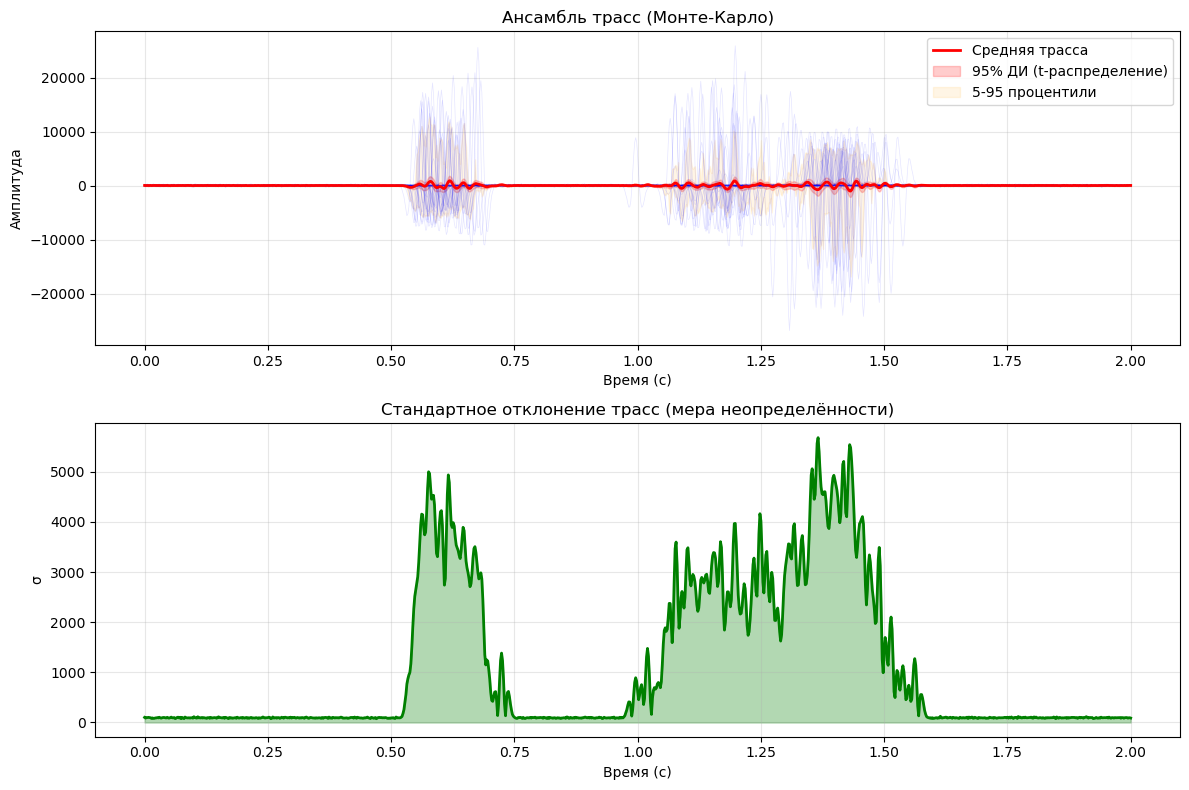

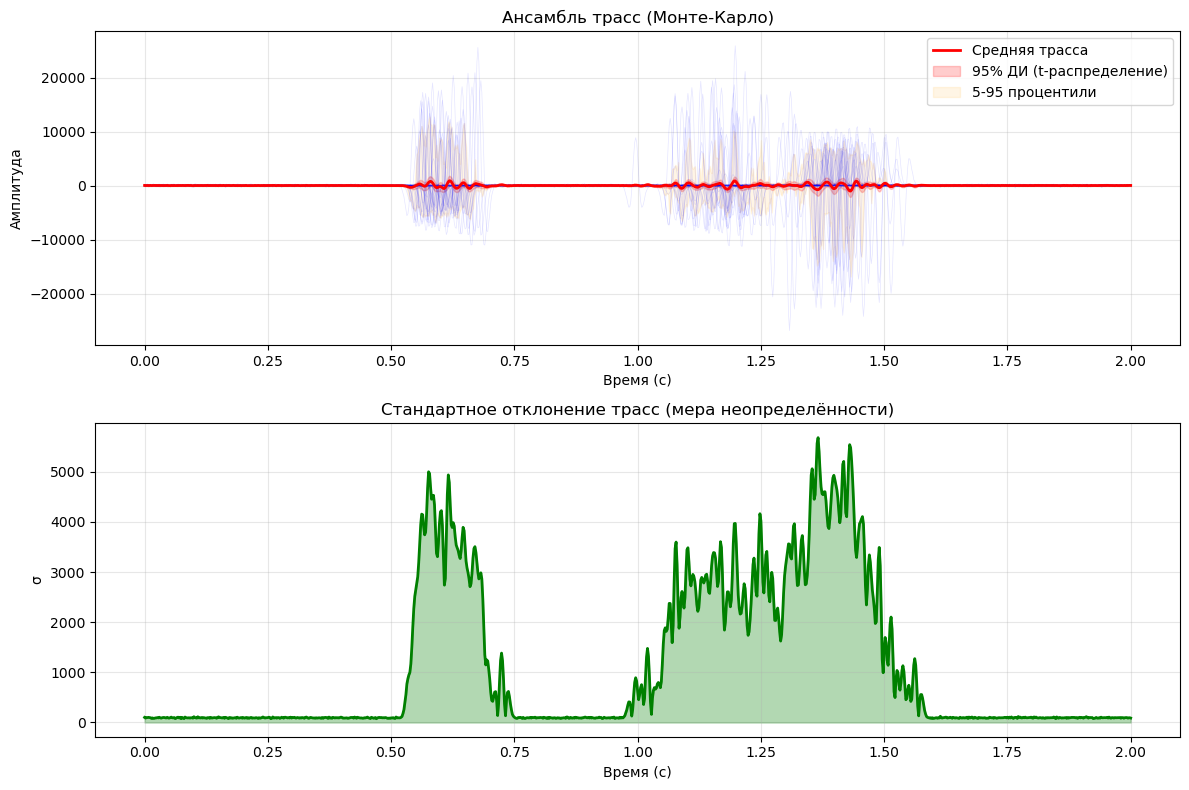

In [66]:
# Визуализация
mc_gen.plot_ensemble(traces, stats, title="Ансамбль трасс (Монте-Карло)")

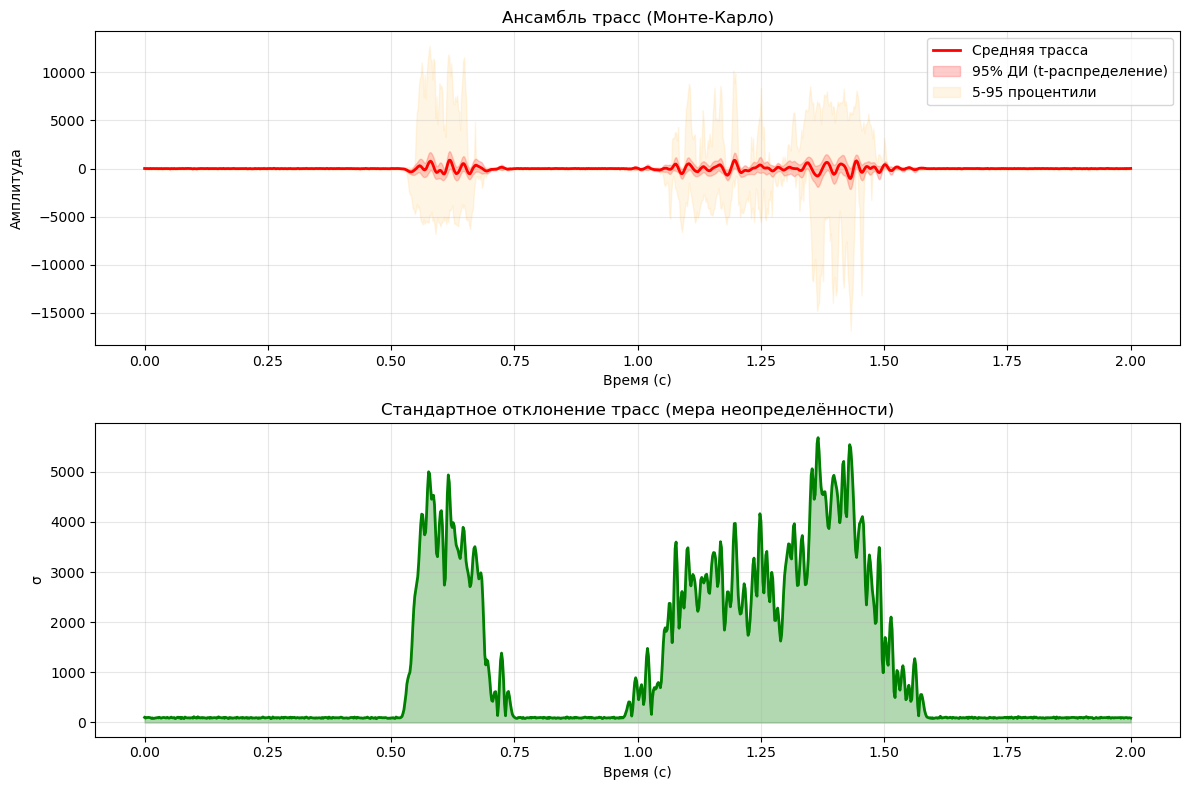

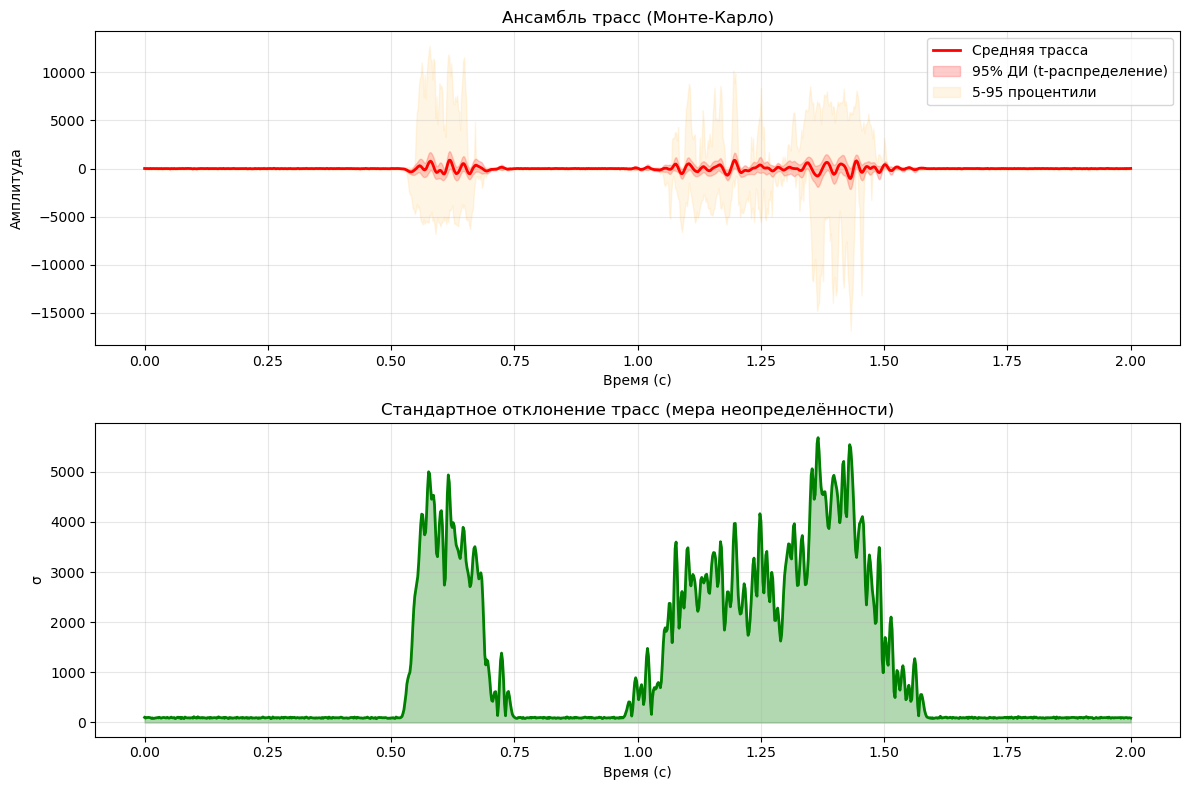

In [67]:
# Визуализация
mc_gen.plot_ensemble(traces, stats, title="Ансамбль трасс (Монте-Карло)", show_individual=False)


Анализ чувствительности: изменение скорости первого слоя


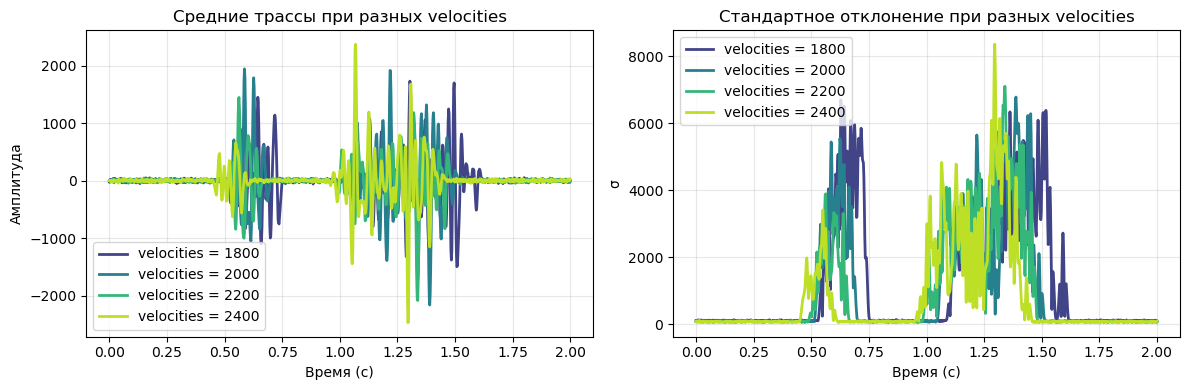

{1800: {'traces': array([[-133.15871744,   11.0725527 ,   87.57874102, ...,   -8.50044499,
          -119.01122706,  -15.67609349],
         [-104.25138003,  -36.96302563,  -63.92501451, ...,   88.74708854,
            59.921729  ,   -7.34974037],
         [ -53.89587746,   30.08702962,   90.56181237, ...,   57.62523963,
            36.79622241,  202.11925585],
         ...,
         [  37.73315689,  -57.0351587 ,  -48.94913591, ...,  -95.60342935,
            37.10873894,  -73.91871214],
         [ -80.90583547,  133.60359533,   75.66701426, ...,  200.12340042,
            85.77688702,  -67.93867474],
         [  41.05219802,  -31.38441608,    5.68255398, ..., -129.61095671,
            75.76140424,  169.78984233]], shape=(30, 1001)),
  'stats': {'mean': array([-23.2902867 ,  16.01632645,  22.49384011, ...,  -6.87025248,
          -13.01065951,   3.66721257], shape=(1001,)),
   'std': array([113.12822539, 111.53529672,  85.70294173, ..., 100.59695262,
          117.43169455, 102.43403

In [68]:
print("\nАнализ чувствительности: изменение скорости первого слоя")
mc_gen.analyze_sensitivity(
    distributions, 
    'velocities', 
    [1800, 2000, 2200, 2400],
    M=30
)

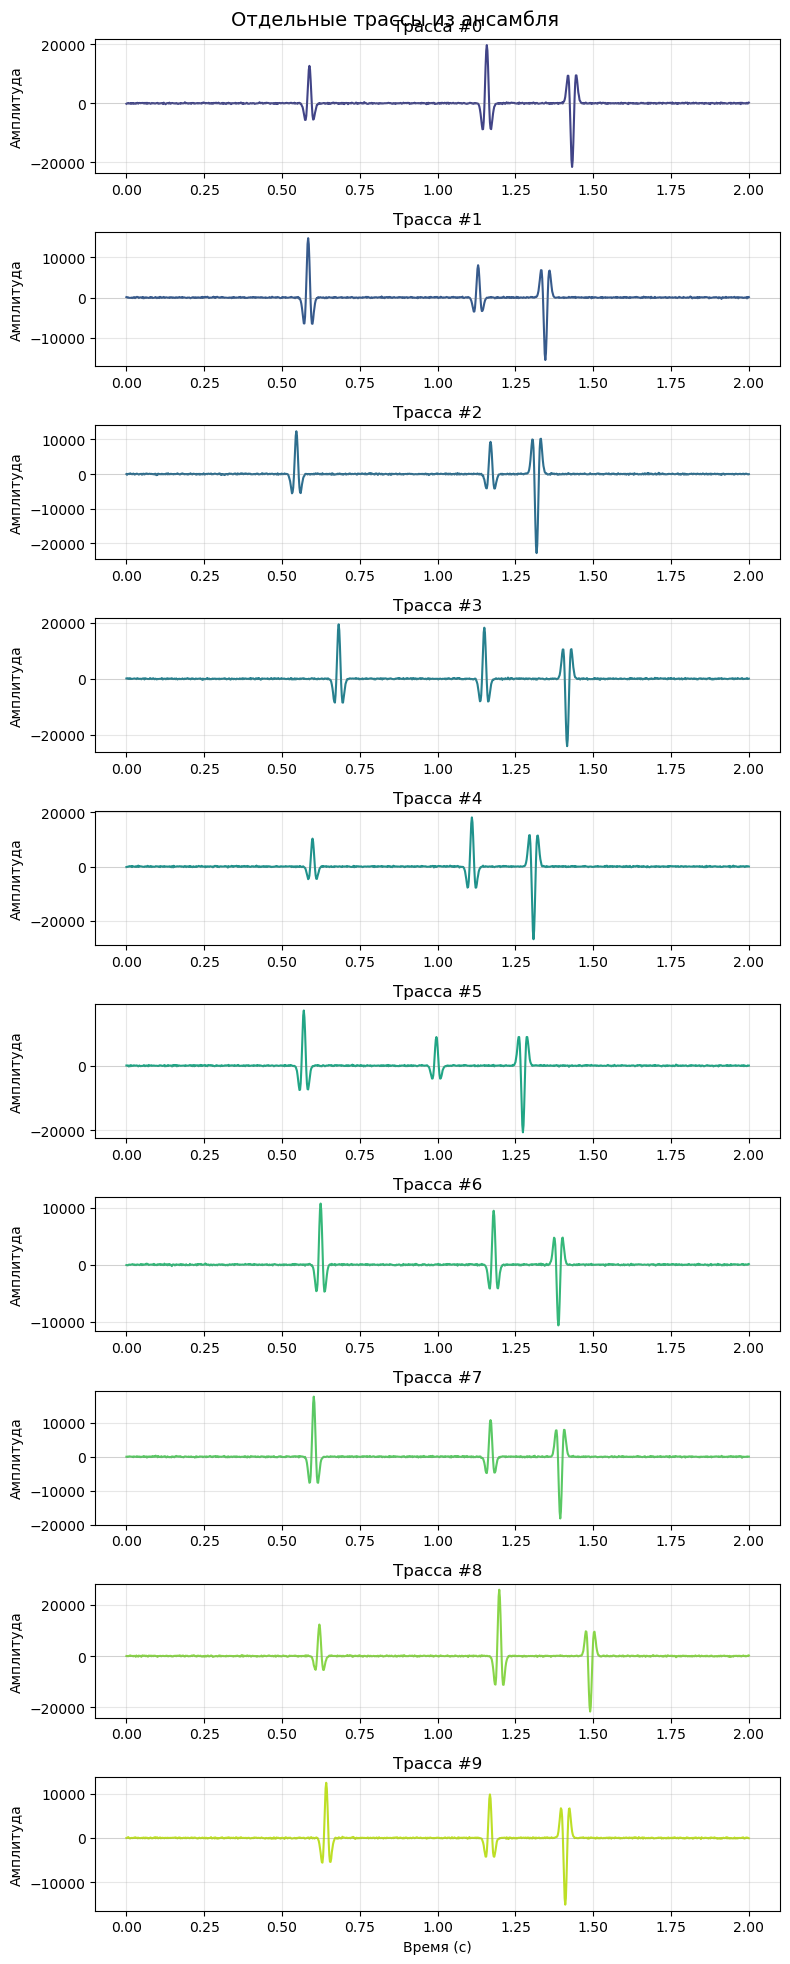

In [69]:
mc_gen.plot_individual_traces(traces, num_traces=10)

In [70]:
save_traces_to_sgy(traces, 2, filename="demo_monte_carlo.sgy",
                   title="demo_monte_carlo")


Файл сохранён: demo_monte_carlo.sgy
  Трасс: 100
  Отсчётов на трассу: 1001
  Интервал: 2 мс (2000 мкс)


'demo_monte_carlo.sgy'